In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import OneHotEncoder
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import pickle
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import load_model

In [3]:
df=pd.read_csv("weather_data.csv")
df

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622
...,...,...,...,...,...,...
999995,Dallas,2024-01-01 20:29:48,23.416877,37.705024,3.819833,16.538119
999996,San Antonio,2024-01-20 15:59:48,6.759080,40.731036,8.182785,29.005558
999997,New York,2024-04-14 08:30:09,15.664465,62.201884,3.987558,0.403909
999998,Chicago,2024-05-12 20:10:43,18.999994,63.703245,4.294325,6.326036


In [4]:
df.shape


(1000000, 6)

In [5]:
df.describe()

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  object 
 1   Date_Time         1000000 non-null  object 
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 45.8+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], errors='coerce')

In [9]:
df['day'] = df['Date_Time'].dt.day
df['month'] = df['Date_Time'].dt.month
df['year'] = df['Date_Time'].dt.year
df['hour'] = df['Date_Time'].dt.hour

In [10]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [11]:
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [12]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['Location']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Location']))
df = pd.concat([df, encoded_df], axis=1)

In [13]:
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,day,month,year,hour,...,Location_Chicago,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540,14,1,2024,21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161,17,5,2024,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951,11,5,2024,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303,26,2,2024,17,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622,29,4,2024,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [14]:
df.to_csv('cleaned_data.csv', index=False)

In [15]:
location_columns = [col for col in df.columns if col.startswith('Location_')]
location_columns


['Location_Chicago',
 'Location_Dallas',
 'Location_Houston',
 'Location_Los Angeles',
 'Location_New York',
 'Location_Philadelphia',
 'Location_Phoenix',
 'Location_San Antonio',
 'Location_San Diego',
 'Location_San Jose']

In [16]:
X = df[['day','month','year','hour',
        'month_sin','month_cos','day_sin','day_cos'] + location_columns]

y = df[['Temperature_C','Humidity_pct','Precipitation_mm','Wind_Speed_kmh']]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
X_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)


Temperature_scaler = MinMaxScaler().fit(y_train[['Temperature_C']])
Humidity_scaler    = MinMaxScaler().fit(y_train[['Humidity_pct']])
Prec_scaler        = MinMaxScaler().fit(y_train[['Precipitation_mm']])
Wind_scaler        = MinMaxScaler().fit(y_train[['Wind_Speed_kmh']])



y_train_scaled = np.hstack([
    Temperature_scaler.transform(y_train[['Temperature_C']]),
    Humidity_scaler.transform(y_train[['Humidity_pct']]),
    Prec_scaler.transform(y_train[['Precipitation_mm']]),
    Wind_scaler.transform(y_train[['Wind_Speed_kmh']])
])

y_test_scaled = np.hstack([
    Temperature_scaler.transform(y_test[['Temperature_C']]),
    Humidity_scaler.transform(y_test[['Humidity_pct']]),
    Prec_scaler.transform(y_test[['Precipitation_mm']]),
    Wind_scaler.transform(y_test[['Wind_Speed_kmh']])
])


X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))


In [19]:

all_scalers = {
    "X_scaler": X_scaler,
    "Temperature_scaler": Temperature_scaler,
    "Humidity_scaler": Humidity_scaler,
    "Prec_scaler": Prec_scaler,
    "Wind_scaler": Wind_scaler
}

with open('all_scalers.pkl', 'wb') as f:
    pickle.dump(all_scalers, f)

print("All scalers saved successfully!")

All scalers saved successfully!


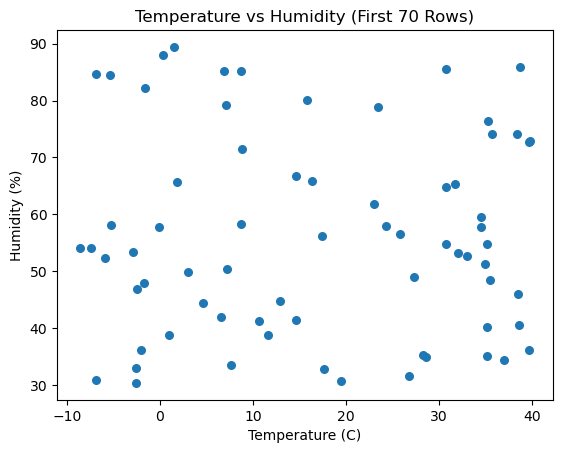

In [20]:
df_small = df.head(70)
plt.scatter(df_small['Temperature_C'], df_small['Humidity_pct'], s=30)
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity (First 70 Rows)")
plt.show()

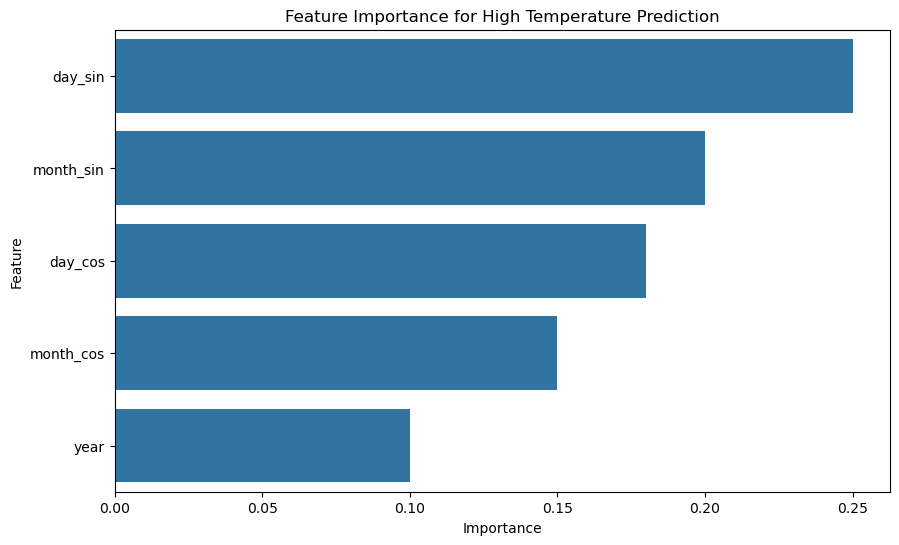

In [21]:
selected_features = ['month_sin','month_cos','day_sin','day_cos','year']
importances = [0.2, 0.15, 0.25, 0.18, 0.1]

feature_importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for High Temperature Prediction')
plt.show()

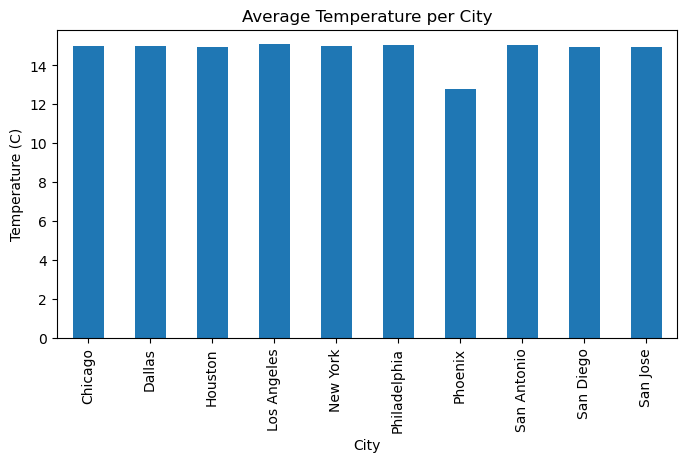

In [22]:
city_avg = df.groupby('Location')['Temperature_C'].mean()

plt.figure(figsize=(8, 4))
city_avg.plot(kind='bar')
plt.title('Average Temperature per City')
plt.ylabel('Temperature (C)')
plt.xlabel('City')
plt.show()


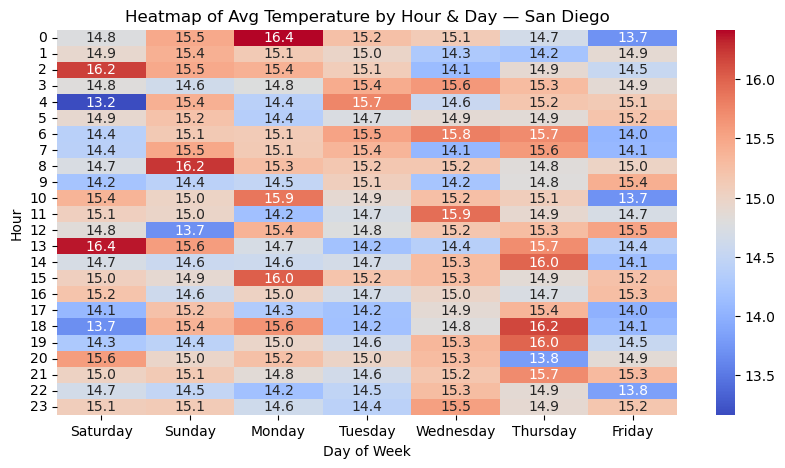

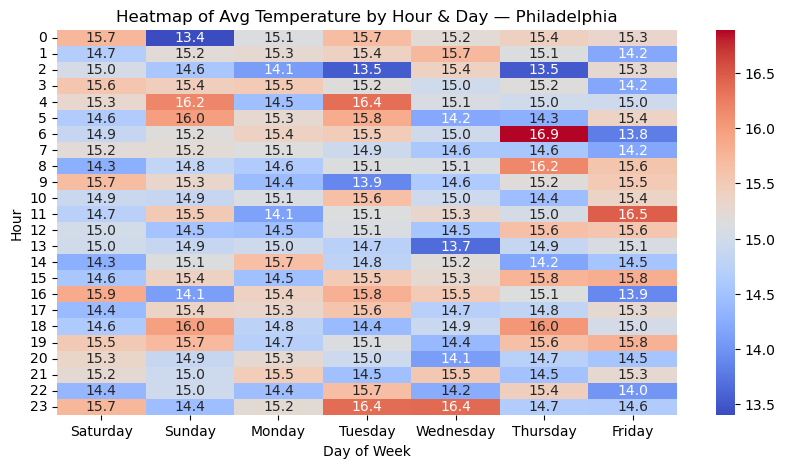

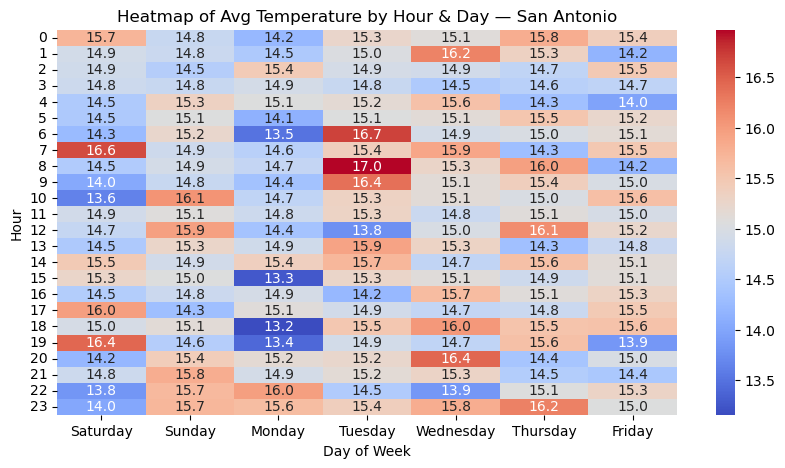

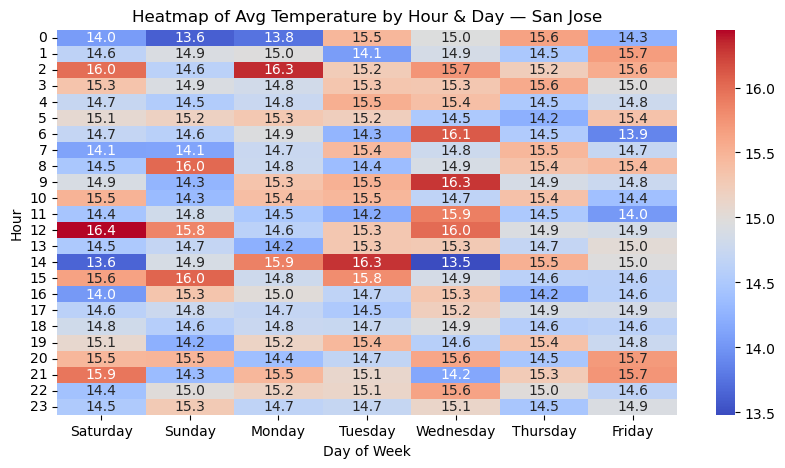

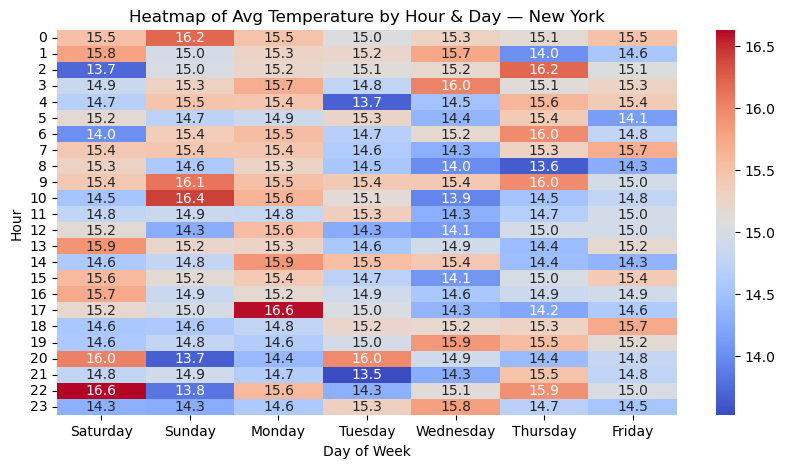

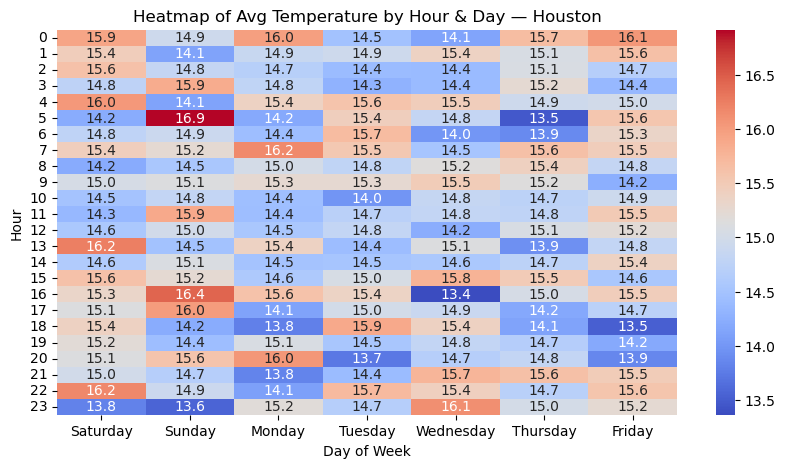

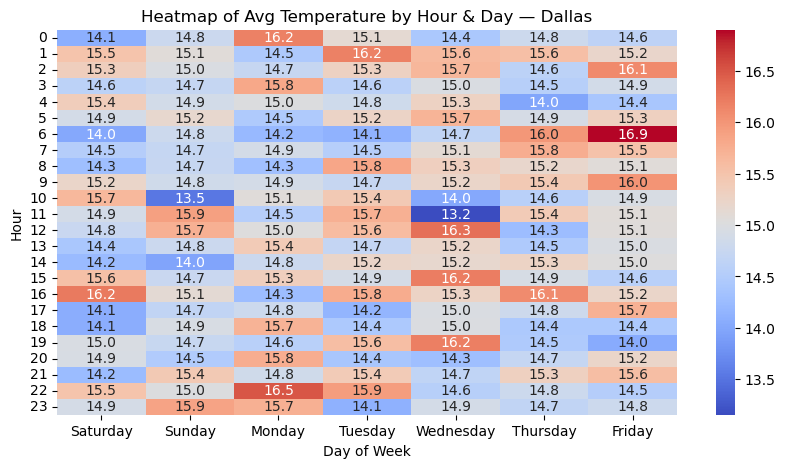

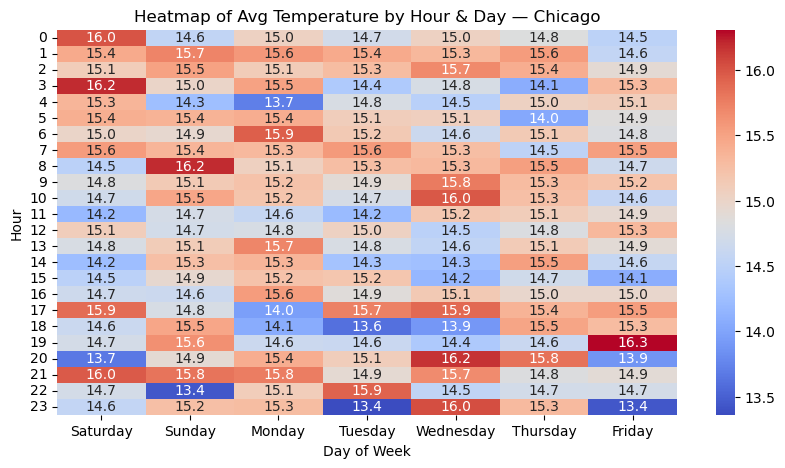

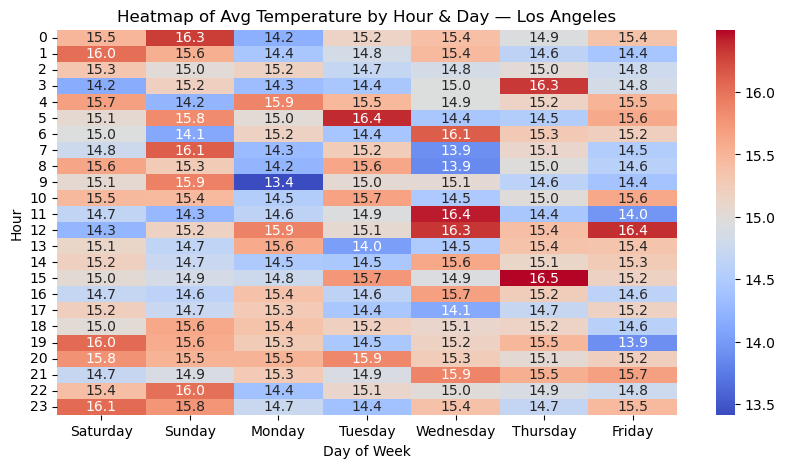

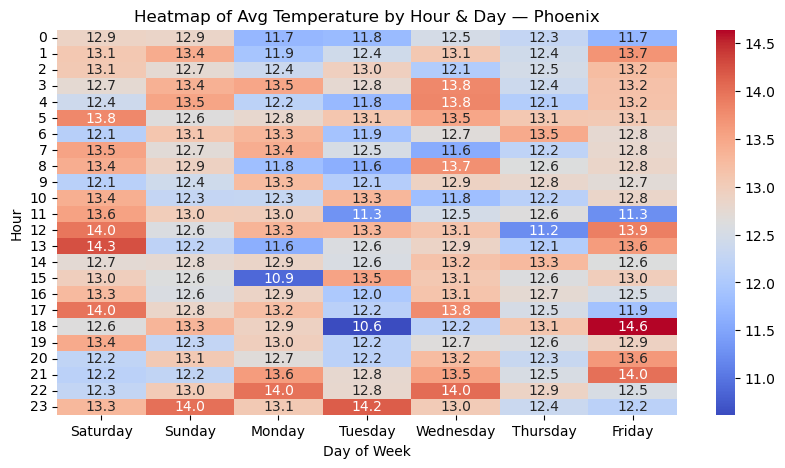

In [23]:
cities = df['Location'].unique()
df['day_of_week'] = df['Date_Time'].dt.day_name()
days_order = ['Saturday','Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday' ]

for city in cities:
    city_df = df[df['Location'] == city]
    pivot_table = city_df.pivot_table(
        values='Temperature_C',
        index='hour',
        columns='day_of_week',
        aggfunc='mean'
    ).reindex(columns=days_order)

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".1f")
    plt.title(f'Heatmap of Avg Temperature by Hour & Day — {city}')
    plt.xlabel('Day of Week')
    plt.ylabel('Hour')
    plt.show()

In [54]:
model = Sequential([
    SimpleRNN(64, activation='tanh', 
              input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]),
              return_sequences=True),

    SimpleRNN(48, activation='tanh', return_sequences=True),  

    SimpleRNN(32, activation='tanh', return_sequences=True),   

    SimpleRNN(16, activation='tanh', return_sequences=False),

    Dense(32, activation='relu'),
    Dense(4, activation='linear')
])

C:\Users\basma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [56]:
early = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    X_train_rnn, y_train_scaled,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1,
    callbacks=[early]
)

Epoch 1/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 206s 10ms/step - loss: 0.0661 - mae: 0.2197 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 2/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 188s 9ms/step - loss: 0.0658 - mae: 0.2194 - val_loss: 0.0657 - val_mae: 0.2192
Epoch 3/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 426s 21ms/step - loss: 0.0658 - mae: 0.2193 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 4/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 206s 9ms/step - loss: 0.0657 - mae: 0.2193 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 5/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 176s 9ms/step - loss: 0.0658 - mae: 0.2194 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 6/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 176s 9ms/step - loss: 0.0657 - mae: 0.2193 - val_loss: 0.0657 - val_mae: 0.2191
Epoch 7/15
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 176s 9ms/step - loss: 0.0658 - mae: 0.2194 - val_loss: 0.0657 - val_mae: 0.2192


In [58]:
y_pred_scaled = model.predict(X_test_rnn)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step


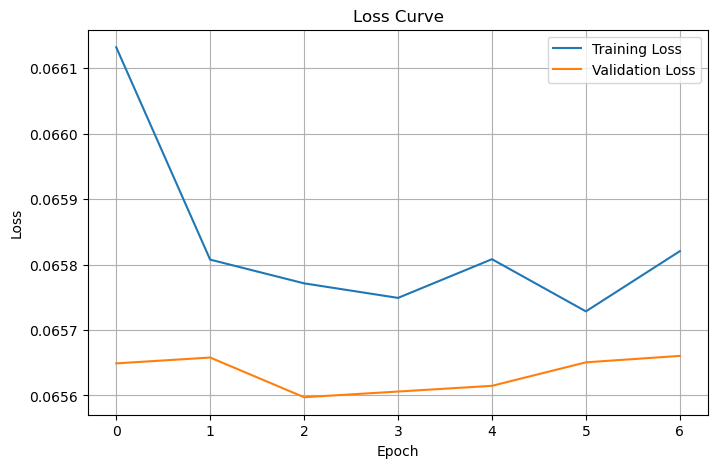

In [59]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [68]:
model.save('my_model.h5')
print("Model saved successfully as my_model.h5")

Model saved successfully as my_model.h5
